In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pickle

In [2]:
dataset = pd.read_csv('diabetes.csv')

#Dataset info


In [3]:
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
dataset.shape

(768, 9)

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


# **Count Null Values**

In [7]:
dataset.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


# Data Visualization


<Axes: xlabel='Outcome', ylabel='count'>

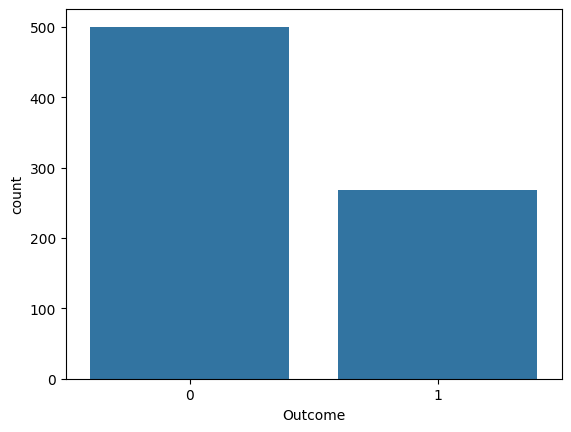

In [8]:
sns.countplot(x= 'Outcome', data=dataset)

# Histogram View

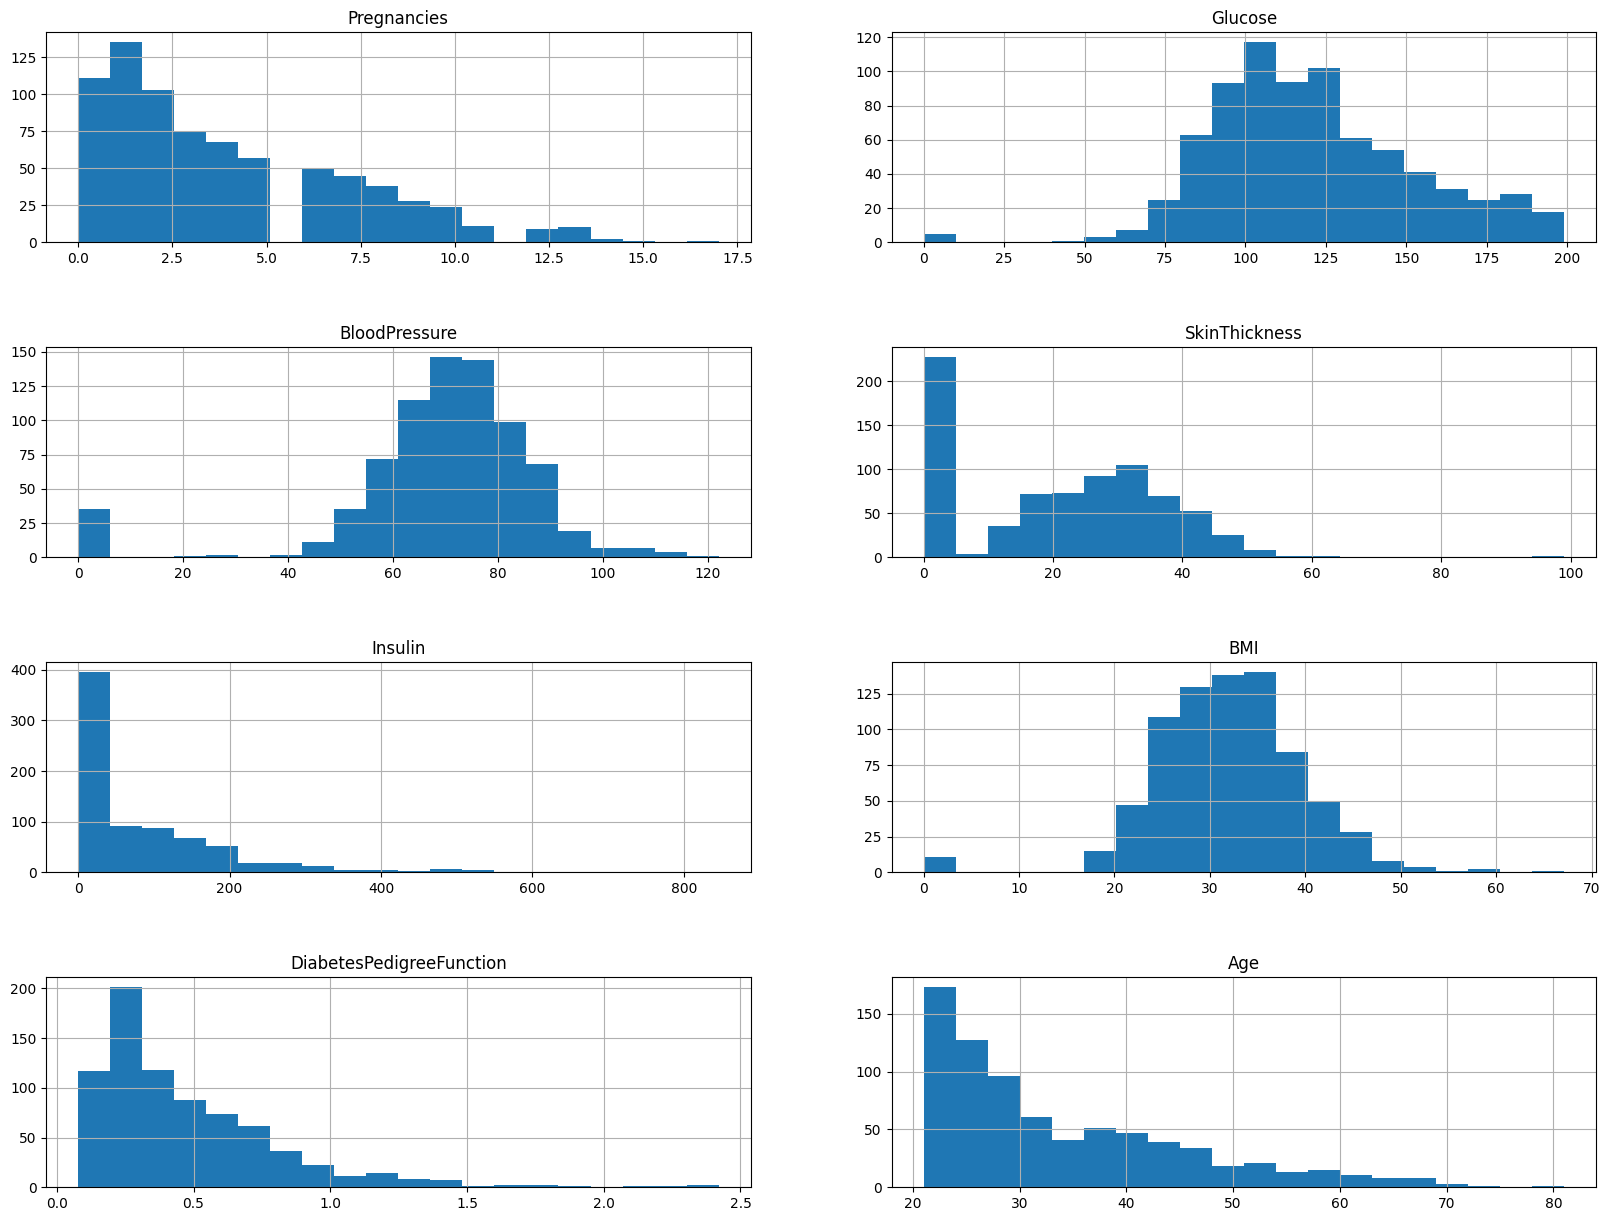

In [9]:
import itertools

col = dataset.columns[:8]
plt.figure(figsize=(20, 15))
length = len(col)

for i, j in itertools.zip_longest(col, range(length)):
    plt.subplot((length // 2) + (length % 2), 2, j + 1)
    plt.subplots_adjust(wspace=0.2, hspace=0.5)
    dataset[i].hist(bins=20)
    plt.title(i)

plt.show()

# Pair plot of dataset

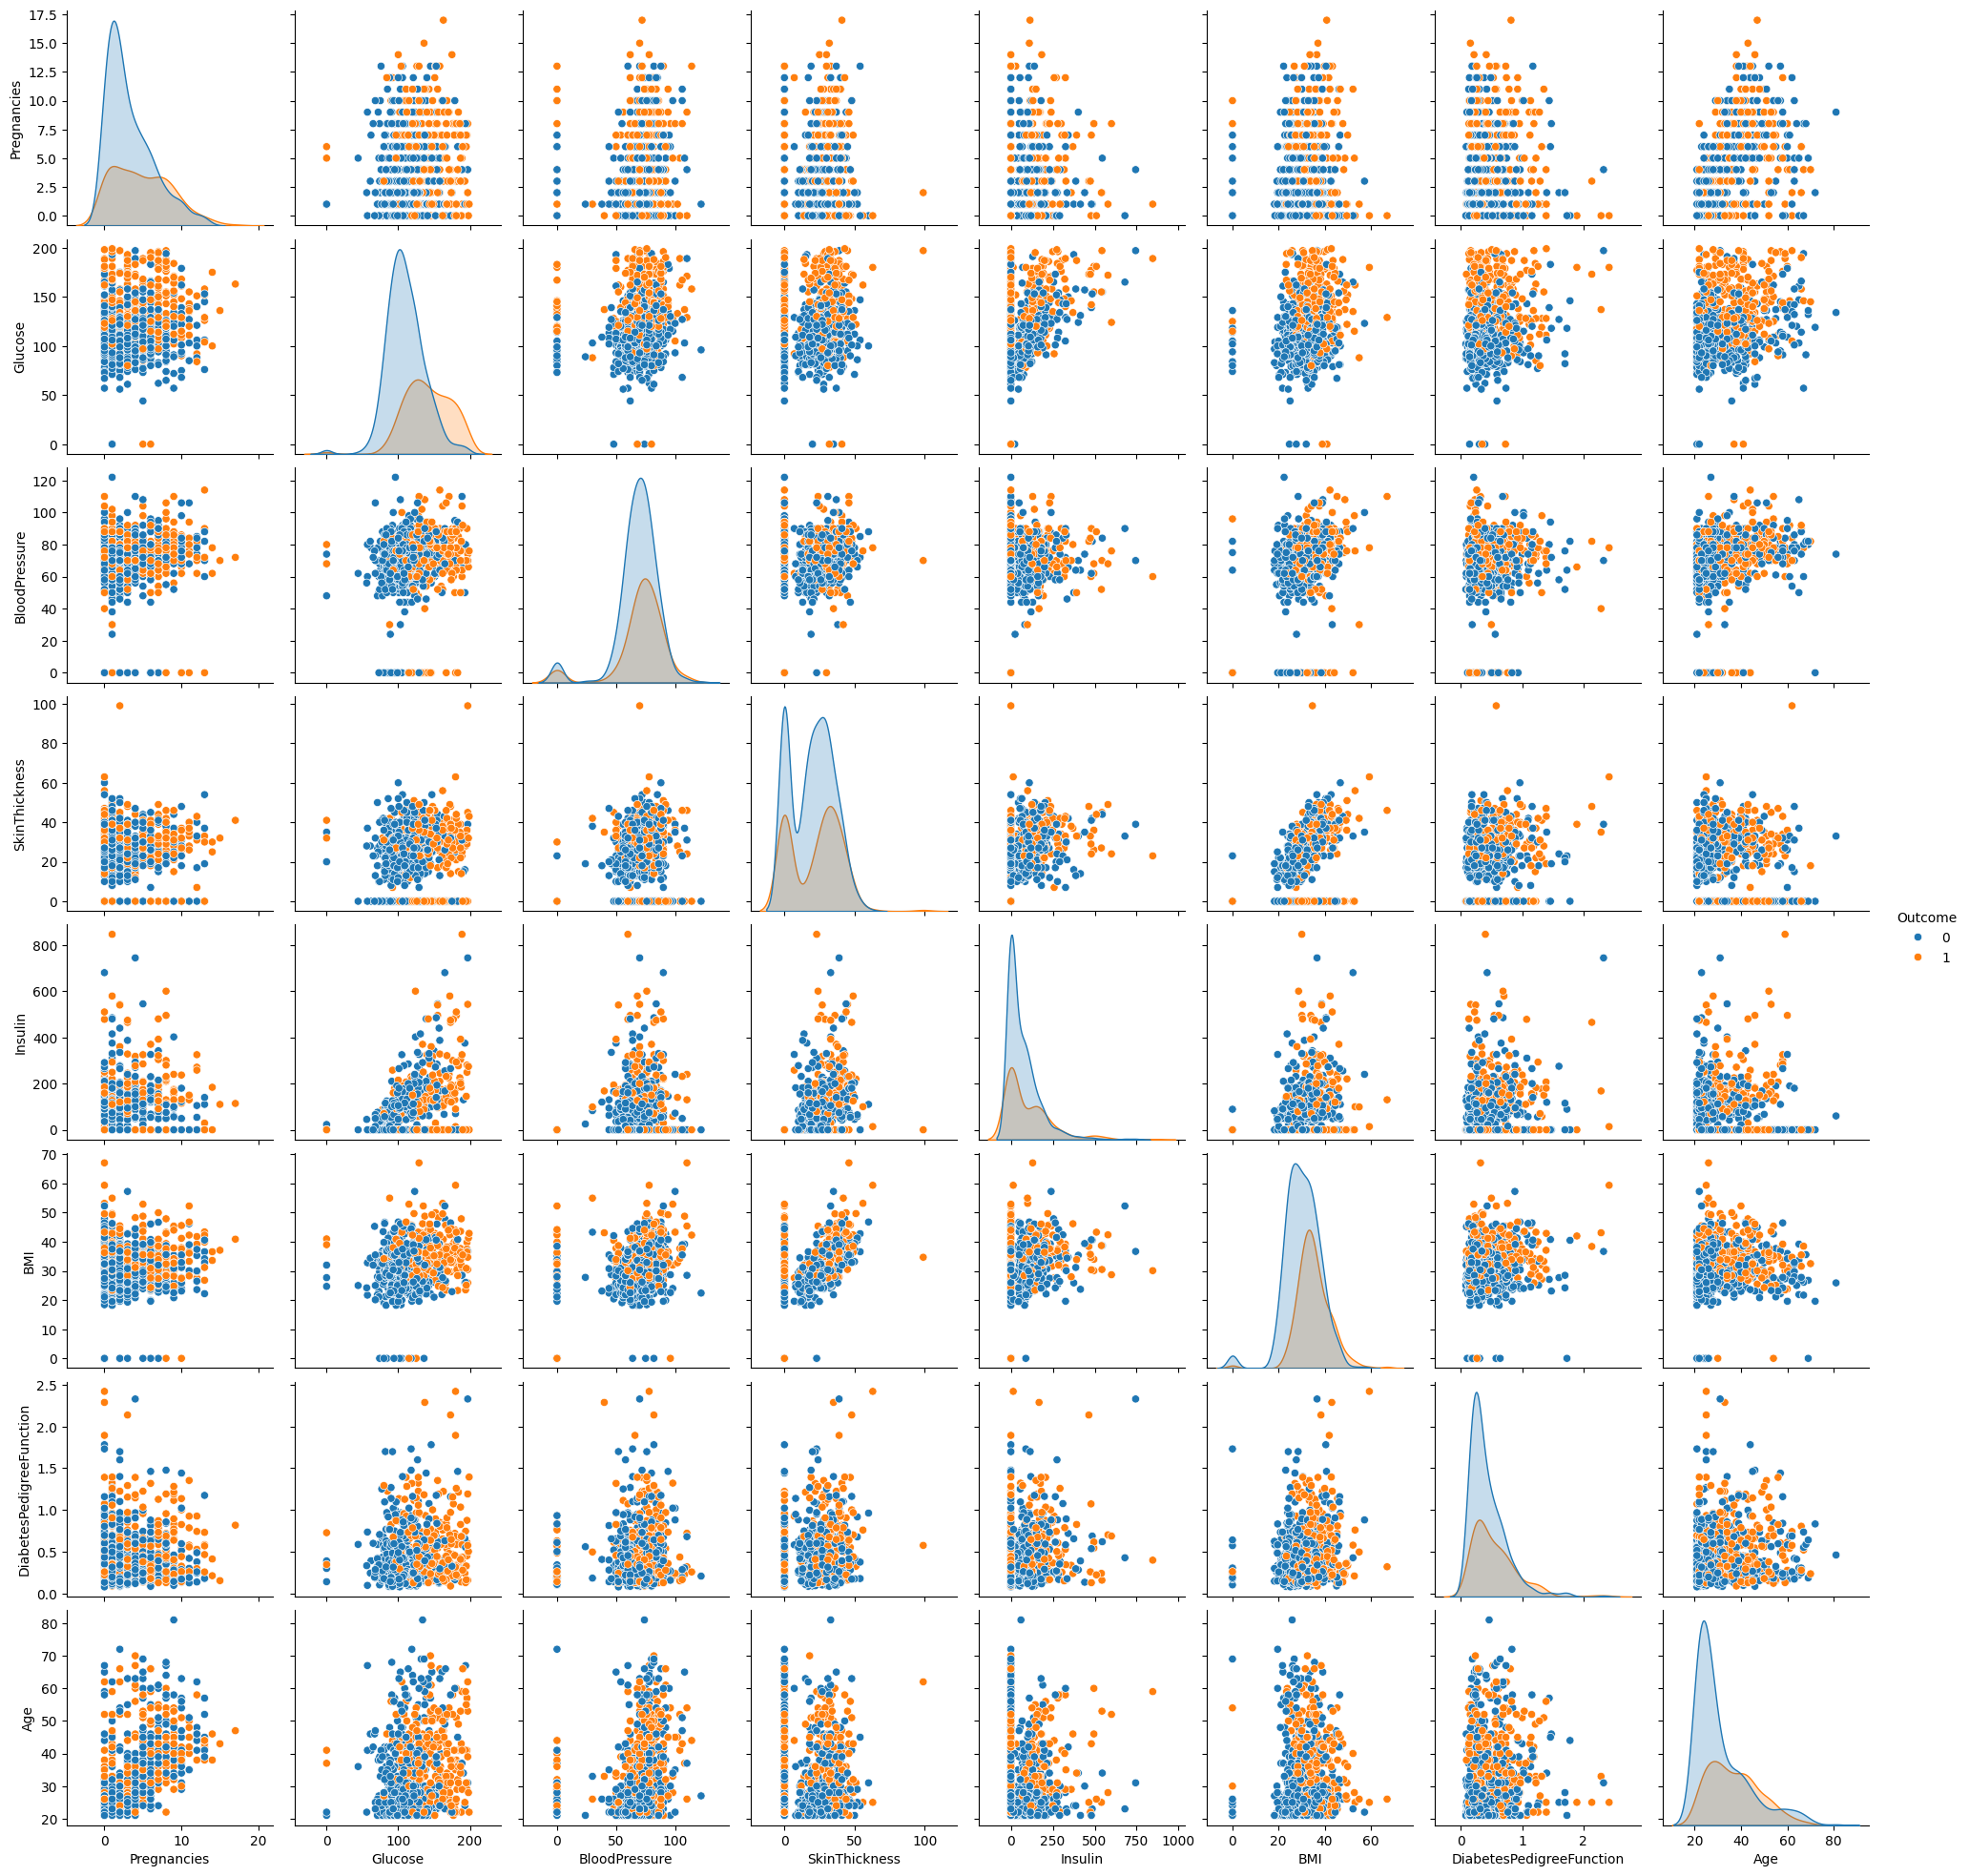

In [10]:
sns.pairplot(data = dataset, hue = 'Outcome')
plt.show()

# Heatmap of Dataset

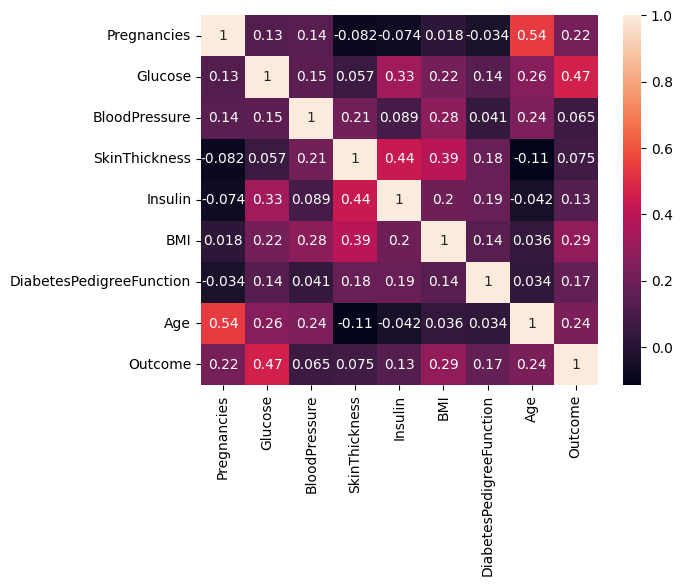

In [11]:
sns.heatmap(dataset.corr(), annot = True)
plt.show()

# Data Processing

In [12]:
dataset_new = dataset

In [13]:
dataset_new[["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]] = dataset_new[["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]].replace(0, np.nan)

In [14]:
dataset_new.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


#Replacing NaN with mean values

In [15]:
dataset_new["Glucose"].fillna(dataset_new["Glucose"].mean(), inplace = True)
dataset_new["BloodPressure"].fillna(dataset_new["BloodPressure"].mean(), inplace = True)
dataset_new["SkinThickness"].fillna(dataset_new["SkinThickness"].mean(), inplace = True)
dataset_new["Insulin"].fillna(dataset_new["Insulin"].mean(), inplace = True)
dataset_new["BMI"].fillna(dataset_new["BMI"].mean(), inplace = True)

# Statistical summary

In [16]:
dataset_new.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.000000,6.000000,17.00
Glucose,768.0,121.686763,30.435949,44.000,99.75000,117.000000,140.250000,199.00
BloodPressure,768.0,72.405184,12.096346,24.000,64.00000,72.202592,80.000000,122.00
SkinThickness,768.0,29.153420,8.790942,7.000,25.00000,29.153420,32.000000,99.00
Insulin,768.0,155.548223,85.021108,14.000,121.50000,155.548223,155.548223,846.00
BMI,768.0,32.457464,6.875151,18.200,27.50000,32.400000,36.600000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.372500,0.626250,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.000000,41.000000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.000000,1.000000,1.00


# Feature scalling using min max scaller

In [17]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0,1))
dataset_scaled = sc.fit_transform(dataset_new)

In [18]:
dataset_scaled = pd.DataFrame(dataset_scaled)

## Selecting Features

Menggunakan semua 8 fitur untuk hasil klasifikasi yang lebih optimal.

In [19]:
X = dataset_scaled.iloc[:, :8].values   # semua 8 fitur
Y = dataset_scaled.iloc[:, 8].values    # label Outcome
print('Shape X:', X.shape)
print('Shape Y:', Y.shape)

Shape X: (768, 8)
Shape Y: (768,)


## Splitting Data Latih dan Uji

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42, stratify=dataset_new['Outcome']
)
print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('Y_train shape:', Y_train.shape)
print('Y_test shape :', Y_test.shape)

X_train shape: (614, 8)
X_test shape : (154, 8)
Y_train shape: (614,)
Y_test shape : (154,)


---
# 🌲 BAGIAN 1: CLASSIFICATION — Random Forest

Random Forest adalah algoritma ensemble berbasis Decision Tree yang menggabungkan banyak pohon keputusan untuk menghasilkan prediksi yang lebih akurat dan stabil. Dipilih karena robust terhadap overfitting, mendukung analisis feature importance, dan performa tinggi pada dataset tabular.

## Training Model Random Forest

In [21]:
rf = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=42)
rf.fit(X_train, Y_train)
print('Model Random Forest berhasil dilatih.')
print(f'Jumlah pohon: {rf.n_estimators}')

Model Random Forest berhasil dilatih.
Jumlah pohon: 100


## Prediksi & Evaluasi Model

In [22]:
Y_pred_rf = rf.predict(X_test)
score_rf = round(accuracy_score(Y_test, Y_pred_rf) * 100, 2)

print('='*45)
print('     EVALUASI MODEL RANDOM FOREST')
print('='*45)
print(f'Accuracy  : {score_rf}%')
print(f'Precision : {precision_score(Y_test, Y_pred_rf):.4f}')
print(f'Recall    : {recall_score(Y_test, Y_pred_rf):.4f}')
print(f'F1 Score  : {f1_score(Y_test, Y_pred_rf):.4f}')
print('='*45)
print('\nClassification Report:')
print(classification_report(Y_test, Y_pred_rf))

     EVALUASI MODEL RANDOM FOREST
Accuracy  : 74.68%
Precision : 0.6667
Recall    : 0.5556
F1 Score  : 0.6061

Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.85      0.81       100
         1.0       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154



## Confusion Matrix

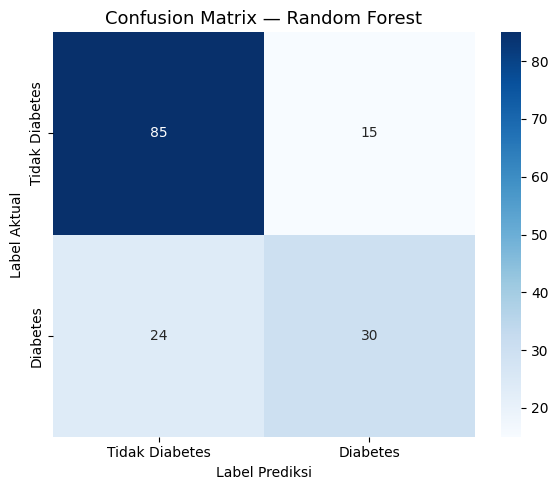

True Negative  (TN): 85
False Positive (FP): 15
False Negative (FN): 24
True Positive  (TP): 30


In [23]:
cm_rf = confusion_matrix(Y_test, Y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Diabetes', 'Diabetes'],
            yticklabels=['Tidak Diabetes', 'Diabetes'])
plt.title('Confusion Matrix — Random Forest', fontsize=13)
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print(f'True Negative  (TN): {tn}')
print(f'False Positive (FP): {fp}')
print(f'False Negative (FN): {fn}')
print(f'True Positive  (TP): {tp}')

## Feature Importance

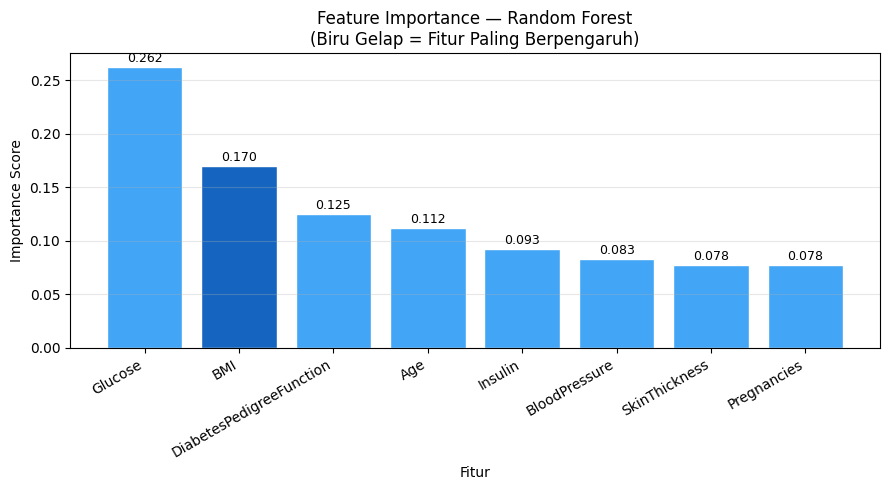

Ranking Feature Importance:
  1. Glucose: 0.2622
  2. BMI: 0.1698
  3. DiabetesPedigreeFunction: 0.1249
  4. Age: 0.1123
  5. Insulin: 0.0926
  6. BloodPressure: 0.0828
  7. SkinThickness: 0.0777
  8. Pregnancies: 0.0777


In [24]:
feature_names = dataset.columns[:8].tolist()
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(9, 5))
colors_fi = ['#1565C0' if i == indices[0] else '#42A5F5' for i in range(len(feature_names))]
bars = plt.bar(range(len(feature_names)),
               importances[indices],
               color=colors_fi, edgecolor='white')
plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in indices], rotation=30, ha='right')
for bar, val in zip(bars, importances[indices]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.title('Feature Importance — Random Forest\n(Biru Gelap = Fitur Paling Berpengaruh)', fontsize=12)
plt.ylabel('Importance Score')
plt.xlabel('Fitur')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Ranking Feature Importance:')
for rank, i in enumerate(indices):
    print(f'  {rank+1}. {feature_names[i]}: {importances[i]:.4f}')

---
# 📊 BAGIAN 1B: CROSS-VALIDATION & PERBANDINGAN MODEL CLASSIFICATION

Untuk memastikan model tidak overfitting dan hasil evaluasi lebih reliable, dilakukan:
1. **Cross-Validation (5-Fold)** pada semua model sebagai baseline
2. **Hyperparameter Tuning** Random Forest dengan RandomizedSearchCV
3. **Perbandingan** semua model: Random Forest (tuned), Logistic Regression, SVM, Decision Tree

## Import Tambahan

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, roc_curve
import time

print('Library tambahan berhasil diimport.')

Library tambahan berhasil diimport.


---
## 🔁 STEP 1: Cross-Validation Baseline (Sebelum Tuning)

Menggunakan **Stratified 5-Fold CV** agar distribusi kelas tetap proporsional di setiap fold.
Ini memberikan estimasi performa yang lebih stabil dibandingkan single train-test split.

In [26]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Definisi model baseline
models_baseline = {
    'Random Forest'       : RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=42),
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'SVM'                 : SVC(kernel='rbf', probability=True, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42)
}

cv_results = {}

print('=' * 55)
print('   CROSS-VALIDATION BASELINE (5-Fold Stratified)')
print('=' * 55)
print(f'{"Model":<22} {"Mean Acc":>9} {"Std":>7} {"Min":>7} {"Max":>7}')
print('-' * 55)

for name, model in models_baseline.items():
    scores = cross_val_score(model, X, Y, cv=skf, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:<22} {scores.mean()*100:>8.2f}%  {scores.std()*100:>5.2f}%  '
          f'{scores.min()*100:>5.2f}%  {scores.max()*100:>5.2f}%')

print('=' * 55)
print('Catatan: Std kecil = model lebih stabil/konsisten')

   CROSS-VALIDATION BASELINE (5-Fold Stratified)
Model                   Mean Acc     Std     Min     Max
-------------------------------------------------------
Random Forest             76.95%   1.81%  75.82%  80.52%
Logistic Regression       76.69%   2.13%  74.51%  80.52%
SVM                       76.17%   2.33%  73.86%  80.52%
Decision Tree             70.30%   5.03%  60.78%  75.32%
Catatan: Std kecil = model lebih stabil/konsisten


---
## 🎯 STEP 2: Hyperparameter Tuning Random Forest (RandomizedSearchCV)

**RandomizedSearchCV** dipilih karena:
- Lebih efisien dari GridSearchCV (tidak coba semua kombinasi)
- Menggunakan `n_iter=50` → mencoba 50 kombinasi random dari search space
- Tetap menggunakan Stratified 5-Fold CV untuk validasi tiap kombinasi

In [27]:
# Search space hyperparameter
param_dist = {
    'n_estimators'      : [50, 100, 150, 200, 300],
    'max_depth'         : [None, 5, 10, 15, 20],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2', None],
    'criterion'         : ['gini', 'entropy'],
    'bootstrap'         : [True, False]
}

rf_base = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator   = rf_base,
    param_distributions = param_dist,
    n_iter      = 50,
    cv          = skf,
    scoring     = 'accuracy',
    n_jobs      = -1,
    random_state= 42,
    verbose     = 1
)

print('Memulai RandomizedSearchCV (50 iterasi, 5-Fold CV)...')
start = time.time()
random_search.fit(X_train, Y_train)
elapsed = time.time() - start

print(f'\nSelesai dalam {elapsed:.1f} detik')
print(f'\nBest Parameters:')
for k, v in random_search.best_params_.items():
    print(f'  {k:<22}: {v}')
print(f'\nBest CV Accuracy: {random_search.best_score_*100:.2f}%')

Memulai RandomizedSearchCV (50 iterasi, 5-Fold CV)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Selesai dalam 130.6 detik

Best Parameters:
  n_estimators          : 100
  min_samples_split     : 2
  min_samples_leaf      : 2
  max_features          : sqrt
  max_depth             : 20
  criterion             : entropy
  bootstrap             : True

Best CV Accuracy: 77.85%


## Evaluasi Random Forest Setelah Tuning

In [28]:
rf_tuned = random_search.best_estimator_
Y_pred_rf_tuned = rf_tuned.predict(X_test)
score_rf_tuned = round(accuracy_score(Y_test, Y_pred_rf_tuned) * 100, 2)

print('=' * 50)
print('   PERBANDINGAN RF SEBELUM vs SESUDAH TUNING')
print('=' * 50)
print(f'{"Metrik":<15} {"RF Default":>12} {"RF Tuned":>12}')
print('-' * 50)
print(f'{"Accuracy":<15} {score_rf:>11.2f}%  {score_rf_tuned:>11.2f}%')
print(f'{"Precision":<15} {precision_score(Y_test, Y_pred_rf):>12.4f}  {precision_score(Y_test, Y_pred_rf_tuned):>12.4f}')
print(f'{"Recall":<15} {recall_score(Y_test, Y_pred_rf):>12.4f}  {recall_score(Y_test, Y_pred_rf_tuned):>12.4f}')
print(f'{"F1 Score":<15} {f1_score(Y_test, Y_pred_rf):>12.4f}  {f1_score(Y_test, Y_pred_rf_tuned):>12.4f}')
print('=' * 50)

print('\nClassification Report (RF Tuned):')
print(classification_report(Y_test, Y_pred_rf_tuned,
      target_names=['Tidak Diabetes', 'Diabetes']))

   PERBANDINGAN RF SEBELUM vs SESUDAH TUNING
Metrik            RF Default     RF Tuned
--------------------------------------------------
Accuracy              74.68%        74.68%
Precision             0.6667        0.6596
Recall                0.5556        0.5741
F1 Score              0.6061        0.6139

Classification Report (RF Tuned):
                precision    recall  f1-score   support

Tidak Diabetes       0.79      0.84      0.81       100
      Diabetes       0.66      0.57      0.61        54

      accuracy                           0.75       154
     macro avg       0.72      0.71      0.71       154
  weighted avg       0.74      0.75      0.74       154



---
## 🤖 STEP 3: Training Model Pembanding

Tiga model pembanding dilatih dengan data yang sama (sudah di-scale dengan MinMaxScaler):
- **Logistic Regression** — model linear, baseline klasik
- **SVM (RBF Kernel)** — model kernel, baik untuk data non-linear
- **Decision Tree** — model tree sederhana, mudah diinterpretasi

In [29]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, Y_train)
Y_pred_lr = lr.predict(X_test)

# SVM
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm.fit(X_train, Y_train)
Y_pred_svm = svm.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, Y_train)
Y_pred_dt = dt.predict(X_test)

print('Semua model pembanding berhasil dilatih.')
print('  - Logistic Regression')
print('  - SVM (RBF Kernel)')
print('  - Decision Tree')

Semua model pembanding berhasil dilatih.
  - Logistic Regression
  - SVM (RBF Kernel)
  - Decision Tree


---
## 📊 STEP 4: Tabel Perbandingan Semua Model

In [30]:
# Kumpulkan semua hasil
all_models = {
    'Random Forest (Default)' : (Y_pred_rf,       rf),
    'Random Forest (Tuned)'   : (Y_pred_rf_tuned,  rf_tuned),
    'Logistic Regression'     : (Y_pred_lr,        lr),
    'SVM (RBF)'               : (Y_pred_svm,       svm),
    'Decision Tree'           : (Y_pred_dt,        dt),
}

comparison_data = []
for name, (y_pred, model) in all_models.items():
    # CV Score
    cv_scores = cross_val_score(model, X, Y, cv=skf, scoring='accuracy')
    # AUC
    if hasattr(model, 'predict_proba'):
        auc = roc_auc_score(Y_test, model.predict_proba(X_test)[:, 1])
    else:
        auc = roc_auc_score(Y_test, model.decision_function(X_test))

    comparison_data.append({
        'Model'       : name,
        'Accuracy'    : round(accuracy_score(Y_test, y_pred) * 100, 2),
        'Precision'   : round(precision_score(Y_test, y_pred), 4),
        'Recall'      : round(recall_score(Y_test, y_pred), 4),
        'F1 Score'    : round(f1_score(Y_test, y_pred), 4),
        'CV Mean Acc' : round(cv_scores.mean() * 100, 2),
        'CV Std'      : round(cv_scores.std() * 100, 2),
        'AUC-ROC'     : round(auc, 4)
    })

df_comparison = pd.DataFrame(comparison_data).set_index('Model')

print('=' * 95)
print('                          PERBANDINGAN SEMUA MODEL CLASSIFICATION')
print('=' * 95)
print(df_comparison.to_string())
print('=' * 95)

best_model_name = df_comparison['F1 Score'].idxmax()
print(f'\n🏆 Model Terbaik (F1 Score tertinggi): {best_model_name}')

                          PERBANDINGAN SEMUA MODEL CLASSIFICATION
                         Accuracy  Precision  Recall  F1 Score  CV Mean Acc  CV Std  AUC-ROC
Model                                                                                       
Random Forest (Default)     74.68     0.6667  0.5556    0.6061        76.95    1.81   0.8140
Random Forest (Tuned)       74.68     0.6596  0.5741    0.6139        76.82    1.99   0.8241
Logistic Regression         70.78     0.6047  0.4815    0.5361        76.69    2.13   0.8087
SVM (RBF)                   72.73     0.6304  0.5370    0.5800        76.17    2.33   0.8031
Decision Tree               66.88     0.5333  0.4444    0.4848        70.30    5.03   0.6172

🏆 Model Terbaik (F1 Score tertinggi): Random Forest (Tuned)


---
## 📈 STEP 5: Visualisasi Perbandingan Model

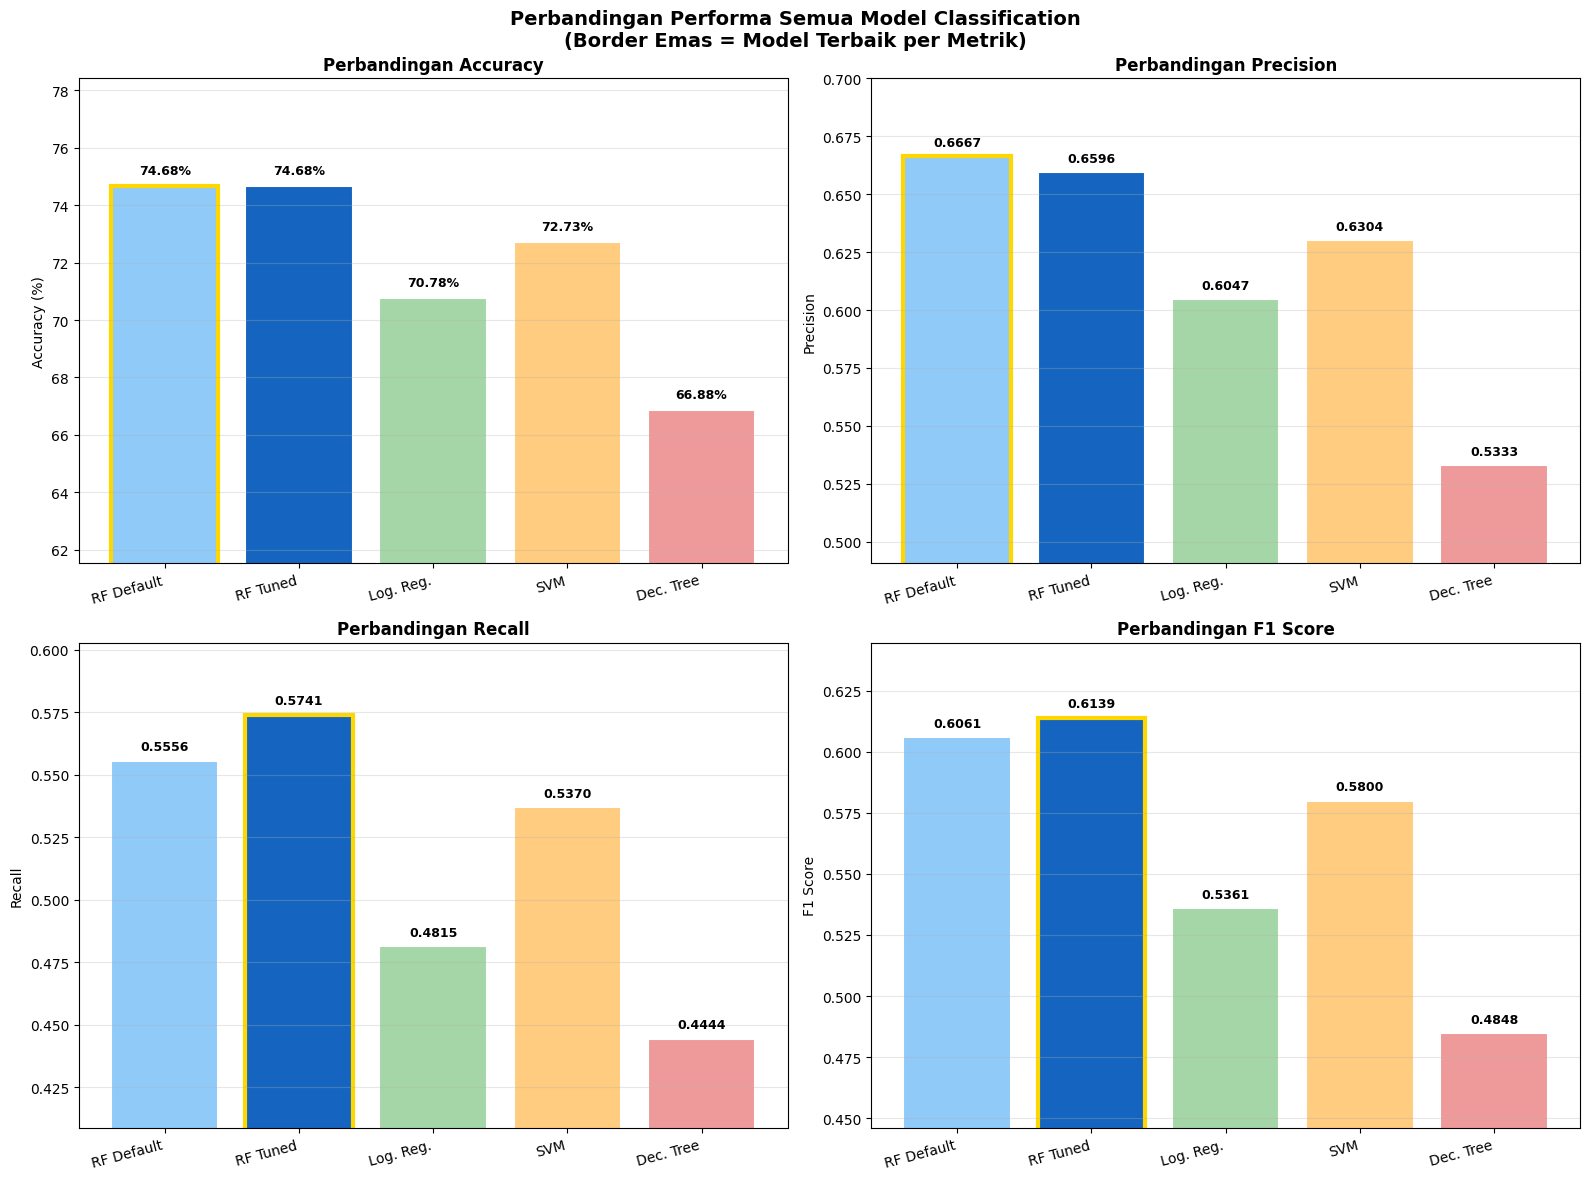

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

model_names_short = ['RF Default', 'RF Tuned', 'Log. Reg.', 'SVM', 'Dec. Tree']
colors_bar = ['#90CAF9', '#1565C0', '#A5D6A7', '#FFCC80', '#EF9A9A']

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
ylabels = ['Accuracy (%)', 'Precision', 'Recall', 'F1 Score']

for idx, (metric, ylabel) in enumerate(zip(metrics, ylabels)):
    ax = axes[idx // 2][idx % 2]
    values = df_comparison[metric].values
    bars = ax.bar(model_names_short, values, color=colors_bar, edgecolor='white', linewidth=1.5)

    # Highlight model terbaik
    best_idx = list(df_comparison.index).index(df_comparison[metric].idxmax())
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

    for bar, val in zip(bars, values):
        label = f'{val:.2f}%' if metric == 'Accuracy' else f'{val:.4f}'
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.3 if metric == 'Accuracy' else 0.003),
                label, ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(f'Perbandingan {metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(model_names_short, rotation=15, ha='right')
    ax.grid(axis='y', alpha=0.3)
    ymin = min(values) * 0.92
    ymax = max(values) * 1.05
    ax.set_ylim(ymin, ymax)

plt.suptitle('Perbandingan Performa Semua Model Classification\n(Border Emas = Model Terbaik per Metrik)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 📉 ROC Curve Semua Model

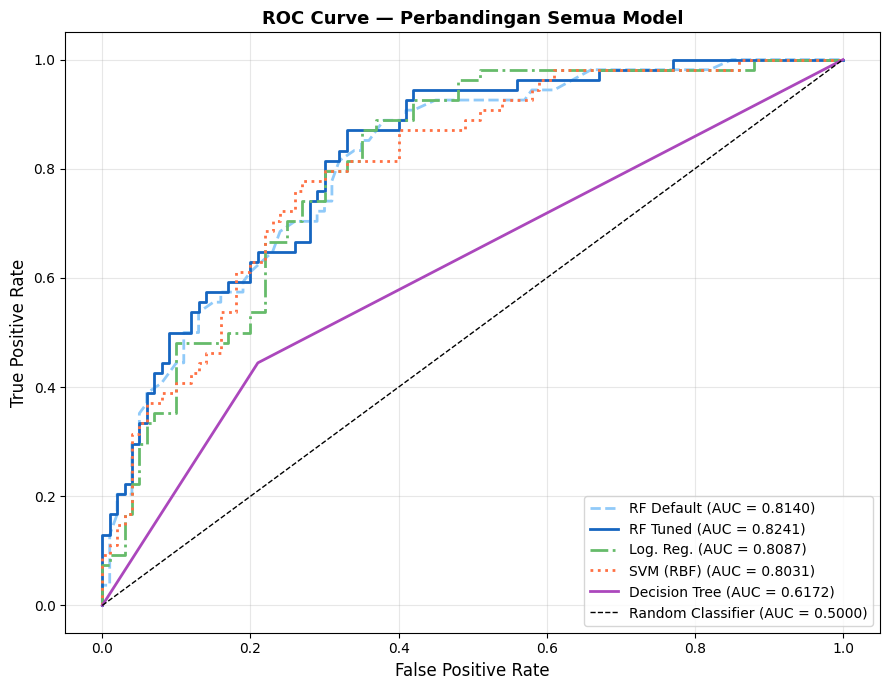

In [32]:
plt.figure(figsize=(9, 7))

roc_models = {
    'RF Default'   : rf,
    'RF Tuned'     : rf_tuned,
    'Log. Reg.'    : lr,
    'SVM (RBF)'    : svm,
    'Decision Tree': dt
}
roc_colors = ['#90CAF9', '#1565C0', '#66BB6A', '#FF7043', '#AB47BC']
roc_styles = ['--', '-', '-.', ':', '-']

for (name, model), color, ls in zip(roc_models.items(), roc_colors, roc_styles):
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(Y_test, y_score)
    auc_val = roc_auc_score(Y_test, y_score)
    plt.plot(fpr, tpr, color=color, linestyle=ls, linewidth=2,
             label=f'{name} (AUC = {auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5000)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Perbandingan Semua Model', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🔁 Cross-Validation Score Comparison (Boxplot)

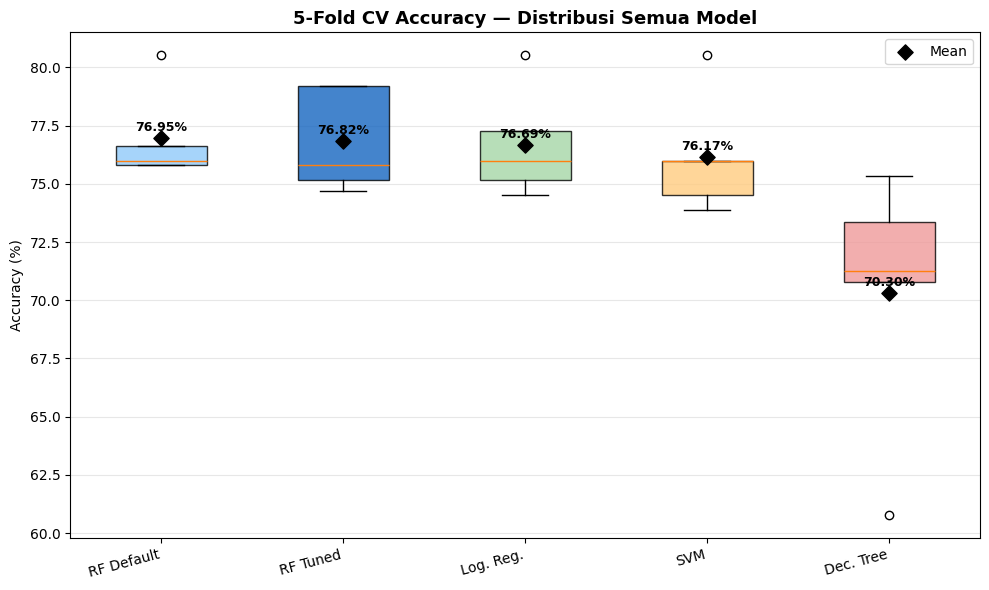


Ringkasan CV Score:
Model               Mean     Std
--------------------------------
RF Default        76.95%  ±1.81%
RF Tuned          76.82%  ±1.99%
Log. Reg.         76.69%  ±2.13%
SVM               76.17%  ±2.33%
Dec. Tree         70.30%  ±5.03%


In [33]:
cv_all = {}
cv_model_map = {
    'RF Default' : rf,
    'RF Tuned'   : rf_tuned,
    'Log. Reg.'  : lr,
    'SVM'        : svm,
    'Dec. Tree'  : dt
}
for name, model in cv_model_map.items():
    cv_all[name] = cross_val_score(model, X, Y, cv=skf, scoring='accuracy') * 100

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(
    [cv_all[m] for m in cv_all],
    labels=list(cv_all.keys()),
    patch_artist=True,
    notch=False,
    widths=0.5
)

for patch, color in zip(bp['boxes'], colors_bar):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

# Tambahkan titik mean
for i, (name, scores) in enumerate(cv_all.items()):
    ax.scatter(i+1, scores.mean(), color='black', marker='D', s=60, zorder=5, label='Mean' if i==0 else '')
    ax.text(i+1, scores.mean() + 0.3, f'{scores.mean():.2f}%',
            ha='center', fontsize=9, fontweight='bold')

ax.set_title('5-Fold CV Accuracy — Distribusi Semua Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_xticklabels(list(cv_all.keys()), rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print('\nRingkasan CV Score:')
print(f'{"Model":<15} {"Mean":>8} {"Std":>7}')
print('-' * 32)
for name, scores in cv_all.items():
    print(f'{name:<15} {scores.mean():>7.2f}%  ±{scores.std():.2f}%')

---
## 💾 Simpan Model Terbaik (Random Forest Tuned)

In [34]:
# Timpa model classification dengan versi yang sudah di-tuning
pickle.dump(rf_tuned, open('model_classification.pkl', 'wb'))
print('Model RF Tuned berhasil disimpan sebagai model_classification.pkl')
print(f'Best Params: {random_search.best_params_}')

Model RF Tuned berhasil disimpan sebagai model_classification.pkl
Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'criterion': 'entropy', 'bootstrap': True}


---
# 🔵 BAGIAN 2: CLUSTERING - K-Means

Clustering digunakan untuk mengelompokkan pasien berdasarkan kesamaan karakteristik medis **tanpa label** (unsupervised learning). Ini berbeda dari klasifikasi — kita ingin menemukan pola tersembunyi dalam data.

## Import Library Clustering

In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

## Persiapan Data untuk Clustering

Clustering menggunakan fitur yang sudah di-scale (MinMaxScaler), tanpa kolom label `Outcome`.

In [36]:
# Gunakan semua 8 fitur (tanpa label Outcome) untuk clustering
X_cluster = dataset_scaled.iloc[:, :8].values
print('Shape data untuk clustering:', X_cluster.shape)

Shape data untuk clustering: (768, 8)


## Mencari K Optimal dengan Elbow Method & Silhouette Score

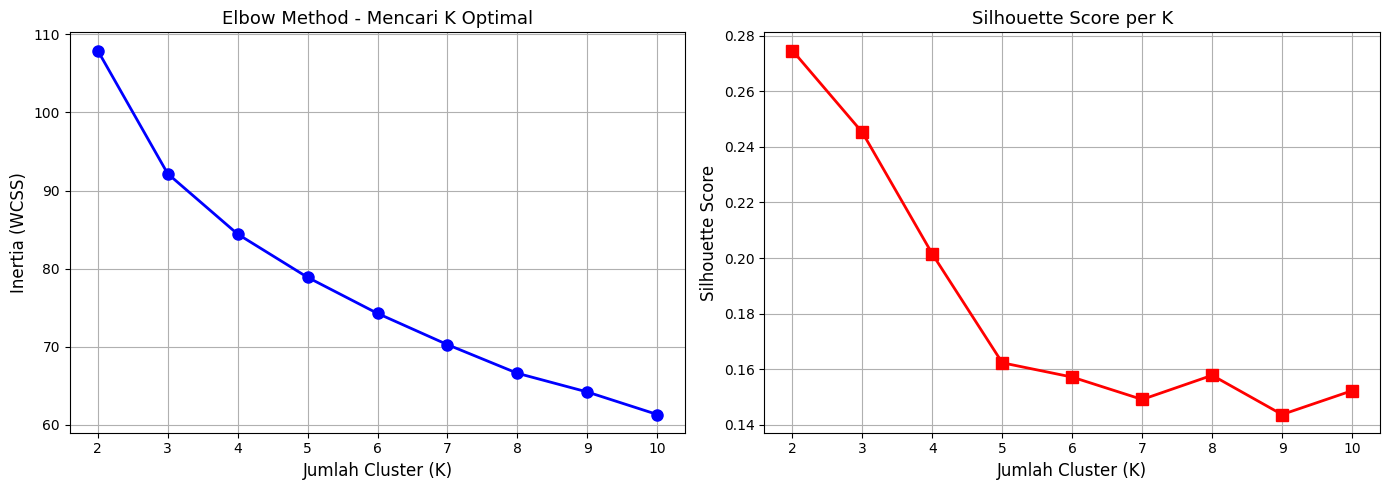

K terbaik berdasarkan Silhouette Score: 2
Silhouette Score tertinggi: 0.2746


In [37]:
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
axes[0].plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Jumlah Cluster (K)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method - Mencari K Optimal', fontsize=13)
axes[0].grid(True)

# Silhouette Score
axes[1].plot(k_range, silhouette_scores, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Jumlah Cluster (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score per K', fontsize=13)
axes[1].grid(True)

plt.tight_layout()
plt.show()

best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f'K terbaik berdasarkan Silhouette Score: {best_k}')
print(f'Silhouette Score tertinggi: {max(silhouette_scores):.4f}')

## Training K-Means dengan K Optimal

In [38]:
best_k = 3  # Berdasarkan hasil elbow & silhouette

kmeans = KMeans(n_clusters=best_k, init='k-means++', random_state=42, n_init=10)
kmeans.fit(X_cluster)
cluster_labels = kmeans.labels_

print(f'Model K-Means berhasil dilatih dengan K={best_k}')
print(f'Inertia (WCSS): {kmeans.inertia_:.4f}')

Model K-Means berhasil dilatih dengan K=3
Inertia (WCSS): 92.1575


## Evaluasi K-Means

In [39]:
sil_score = silhouette_score(X_cluster, cluster_labels)
db_score = davies_bouldin_score(X_cluster, cluster_labels)

print('='*45)
print('       EVALUASI MODEL K-MEANS')
print('='*45)
print(f'Silhouette Score  : {sil_score:.4f}  (mendekati 1 = baik)')
print(f'Davies-Bouldin    : {db_score:.4f}  (mendekati 0 = baik)')
print('='*45)

# Distribusi tiap cluster
print('\nDistribusi data per cluster:')
unique, counts = np.unique(cluster_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} data ({c/len(cluster_labels)*100:.1f}%)')

       EVALUASI MODEL K-MEANS
Silhouette Score  : 0.2452  (mendekati 1 = baik)
Davies-Bouldin    : 1.5791  (mendekati 0 = baik)

Distribusi data per cluster:
  Cluster 0: 227 data (29.6%)
  Cluster 1: 155 data (20.2%)
  Cluster 2: 386 data (50.3%)


## Analisis Karakteristik Tiap Cluster

In [40]:
# Tambahkan cluster label ke dataset asli
dataset_clustered = dataset_new.copy()
dataset_clustered['Cluster'] = cluster_labels

# Statistik rata-rata tiap cluster
cluster_analysis = dataset_clustered.groupby('Cluster').mean().round(2)
print('Rata-rata fitur per Cluster:')
print(cluster_analysis.to_string())

# Persentase diabetes per cluster
print('\nPersentase Diabetes per Cluster:')
for c in range(best_k):
    subset = dataset_clustered[dataset_clustered['Cluster'] == c]
    pct = subset['Outcome'].mean() * 100
    print(f'  Cluster {c}: {pct:.1f}% menderita diabetes ({len(subset)} pasien)')

Rata-rata fitur per Cluster:
         Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  DiabetesPedigreeFunction    Age  Outcome
Cluster                                                                                                              
0               7.72   126.14          77.05          30.22   163.43  32.51                      0.46  46.67     0.49
1               2.55   158.63          76.70          33.76   212.04  37.54                      0.60  31.57     0.68
2               2.08   104.23          67.95          26.68   128.23  30.39                      0.43  26.02     0.13

Persentase Diabetes per Cluster:
  Cluster 0: 48.9% menderita diabetes (227 pasien)
  Cluster 1: 67.7% menderita diabetes (155 pasien)
  Cluster 2: 13.5% menderita diabetes (386 pasien)


## Visualisasi Cluster dengan PCA 2D

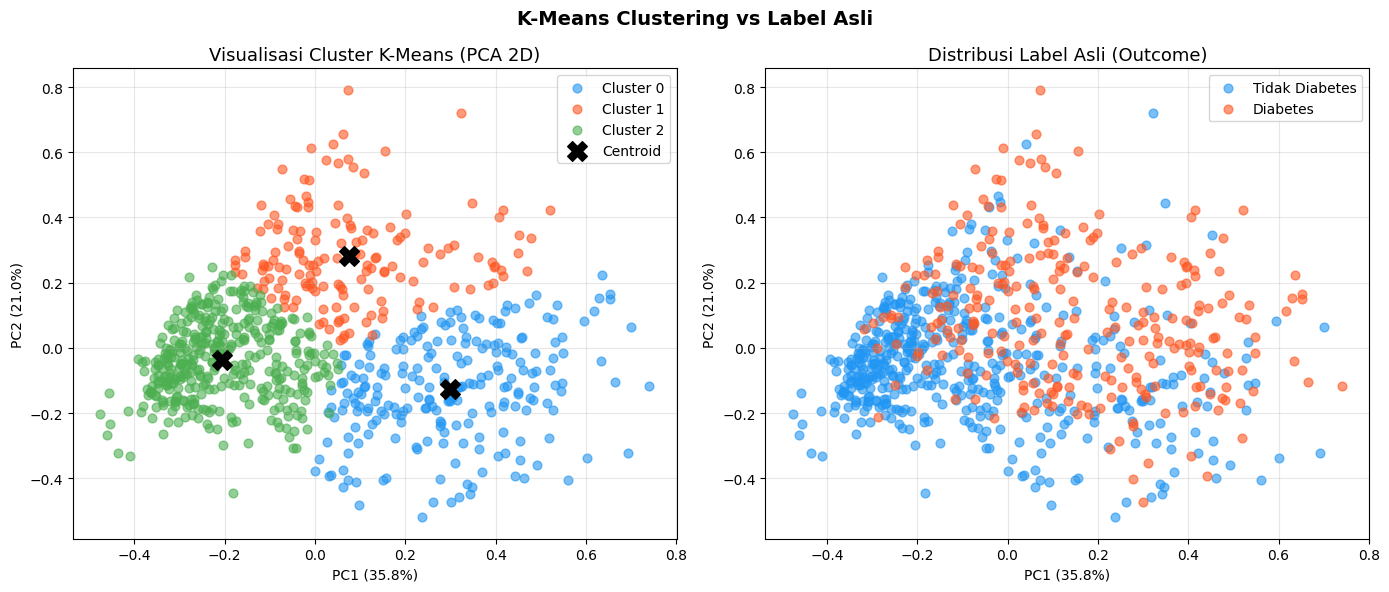

Total variansi yang dijelaskan PCA: 56.8%


In [41]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#2196F3', '#FF5722', '#4CAF50']

# Plot cluster hasil K-Means
for i in range(best_k):
    mask = cluster_labels == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[i], label=f'Cluster {i}', alpha=0.6, s=40)
# Plot centroid
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='black', marker='X', s=200, label='Centroid', zorder=5)
axes[0].set_title('Visualisasi Cluster K-Means (PCA 2D)', fontsize=13)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot label asli (Outcome) untuk perbandingan
outcome_colors = {0: '#2196F3', 1: '#FF5722'}
for outcome, color in outcome_colors.items():
    mask = dataset_new['Outcome'].values == outcome
    label = 'Tidak Diabetes' if outcome == 0 else 'Diabetes'
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=label, alpha=0.6, s=40)
axes[1].set_title('Distribusi Label Asli (Outcome)', fontsize=13)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('K-Means Clustering vs Label Asli', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Total variansi yang dijelaskan PCA: {sum(pca.explained_variance_ratio_)*100:.1f}%')

## Visualisasi Boxplot Fitur per Cluster

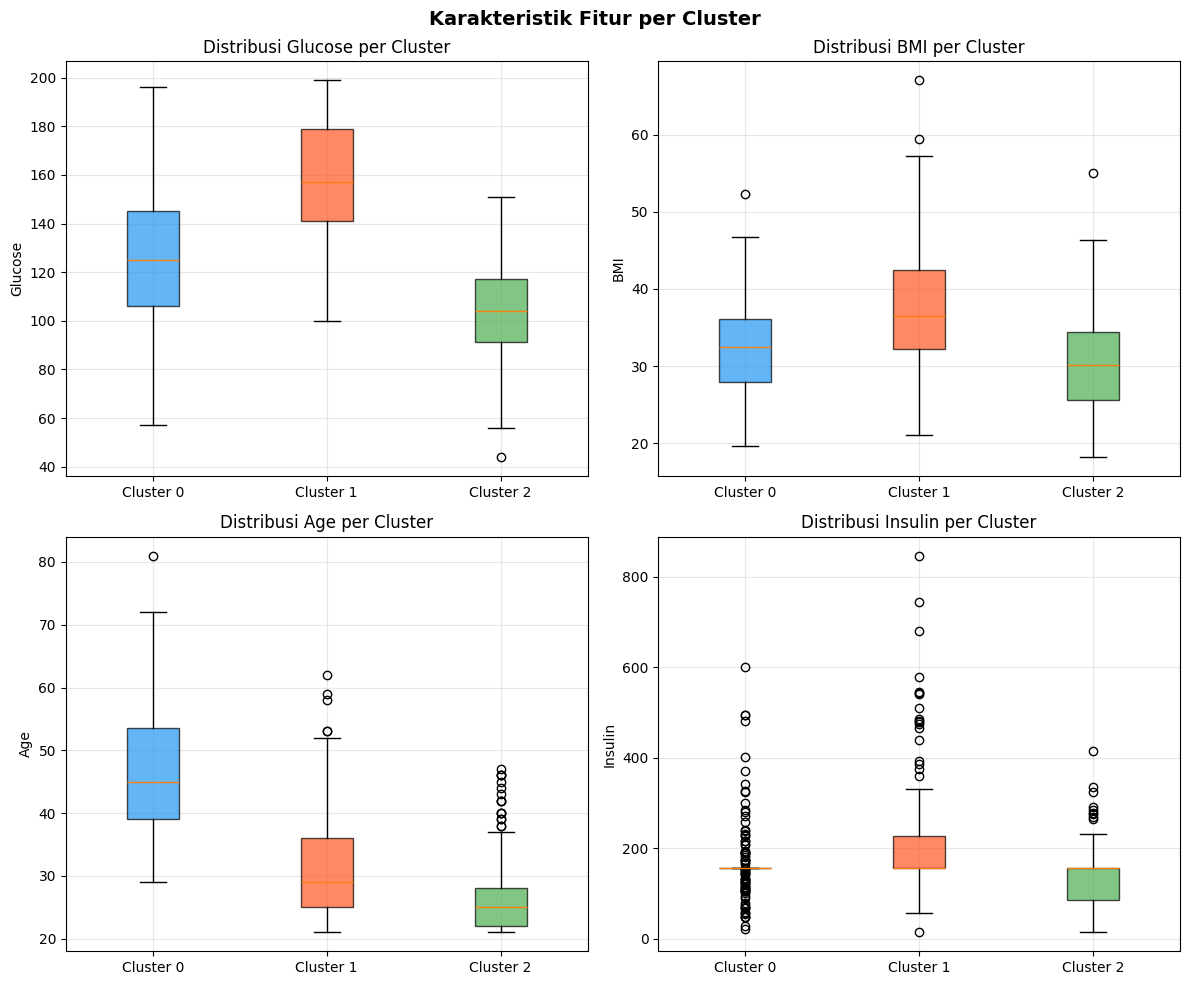

In [42]:
features_to_plot = ['Glucose', 'BMI', 'Age', 'Insulin']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, feat in enumerate(features_to_plot):
    data_per_cluster = [dataset_clustered[dataset_clustered['Cluster']==c][feat].values
                        for c in range(best_k)]
    bp = axes[idx].boxplot(data_per_cluster,
                           patch_artist=True,
                           labels=[f'Cluster {i}' for i in range(best_k)])
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[idx].set_title(f'Distribusi {feat} per Cluster', fontsize=12)
    axes[idx].set_ylabel(feat)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Karakteristik Fitur per Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 🔴 BAGIAN 3: ANOMALY DETECTION - Isolation Forest

Anomaly Detection digunakan untuk mendeteksi data pasien yang memiliki nilai ekstrem/tidak normal (outlier) yang mungkin menunjukkan kondisi medis kritis atau kesalahan pencatatan data.

## Import Library Anomaly Detection

In [43]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report as cr

## Training Isolation Forest

In [44]:
# contamination = estimasi proporsi anomali dalam data
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,   # asumsi ~5% data adalah anomali
    random_state=42,
    max_samples='auto'
)
iso_forest.fit(X_cluster)

# Prediksi: 1 = normal, -1 = anomali
anomaly_pred = iso_forest.predict(X_cluster)
anomaly_scores = iso_forest.decision_function(X_cluster)  # semakin negatif = semakin anomali

# Konversi ke label 0/1 (1=anomali, 0=normal)
anomaly_labels = np.where(anomaly_pred == -1, 1, 0)

n_anomaly = np.sum(anomaly_labels == 1)
n_normal = np.sum(anomaly_labels == 0)
print('='*45)
print('    HASIL DETEKSI ANOMALI')
print('='*45)
print(f'Total data        : {len(anomaly_labels)}')
print(f'Data Normal       : {n_normal} ({n_normal/len(anomaly_labels)*100:.1f}%)')
print(f'Data Anomali      : {n_anomaly} ({n_anomaly/len(anomaly_labels)*100:.1f}%)')
print('='*45)

    HASIL DETEKSI ANOMALI
Total data        : 768
Data Normal       : 729 (94.9%)
Data Anomali      : 39 (5.1%)


## Analisis Anomaly Score Distribution

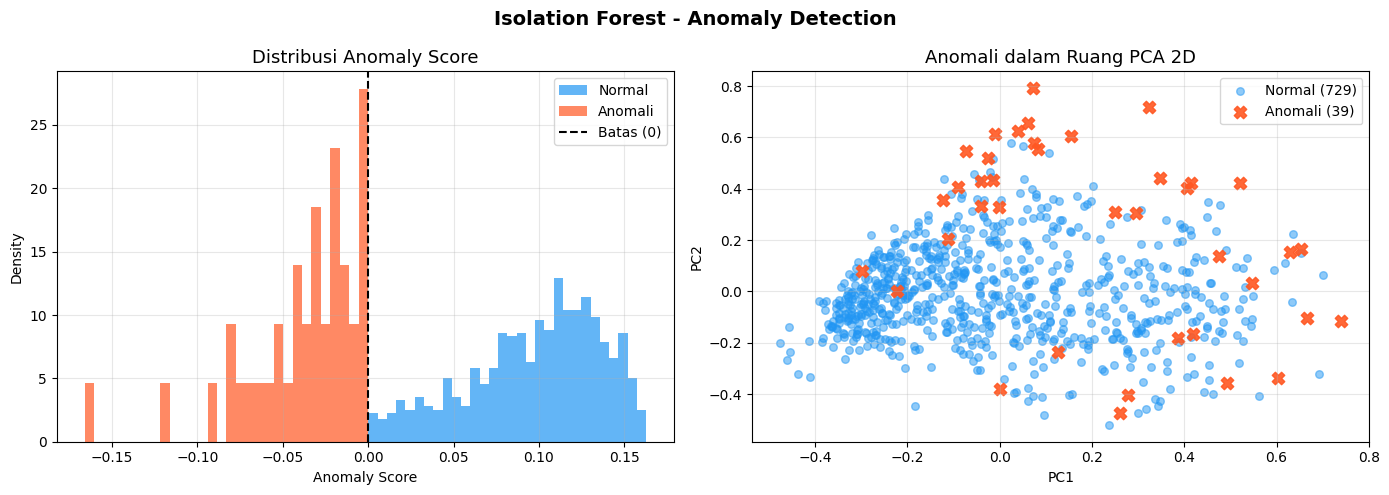

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram anomaly score
axes[0].hist(anomaly_scores[anomaly_labels==0], bins=30, color='#2196F3',
             alpha=0.7, label='Normal', density=True)
axes[0].hist(anomaly_scores[anomaly_labels==1], bins=30, color='#FF5722',
             alpha=0.7, label='Anomali', density=True)
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Batas (0)')
axes[0].set_title('Distribusi Anomaly Score', fontsize=13)
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Visualisasi anomali dalam ruang PCA
axes[1].scatter(X_pca[anomaly_labels==0, 0], X_pca[anomaly_labels==0, 1],
                c='#2196F3', alpha=0.5, s=30, label=f'Normal ({n_normal})')
axes[1].scatter(X_pca[anomaly_labels==1, 0], X_pca[anomaly_labels==1, 1],
                c='#FF5722', alpha=0.9, s=80, marker='X', label=f'Anomali ({n_anomaly})')
axes[1].set_title('Anomali dalam Ruang PCA 2D', fontsize=13)
axes[1].set_xlabel(f'PC1')
axes[1].set_ylabel(f'PC2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Isolation Forest - Anomaly Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Analisis Karakteristik Data Anomali

In [46]:
dataset_anomaly = dataset_new.copy()
dataset_anomaly['Anomaly'] = anomaly_labels
dataset_anomaly['Anomaly_Score'] = anomaly_scores

print('Statistik Data NORMAL:')
print(dataset_anomaly[dataset_anomaly['Anomaly']==0].describe().round(2).to_string())
print('\nStatistik Data ANOMALI:')
print(dataset_anomaly[dataset_anomaly['Anomaly']==1].describe().round(2).to_string())

Statistik Data NORMAL:
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  DiabetesPedigreeFunction     Age  Outcome  Anomaly  Anomaly_Score
count       729.00   729.00         729.00         729.00   729.00  729.00                    729.00  729.00   729.00    729.0         729.00
mean          3.83   120.24          72.28          28.65   147.72   32.06                      0.45   32.89     0.34      0.0           0.10
std           3.29    29.21          11.51           7.94    63.70    6.41                      0.30   11.43     0.47      0.0           0.04
min           0.00    44.00          24.00           8.00    15.00   18.20                      0.08   21.00     0.00      0.0           0.00
25%           1.00    99.00          64.00          25.00   120.00   27.40                      0.24   24.00     0.00      0.0           0.07
50%           3.00   116.00          72.00          29.15   155.55   32.00                      0.36   29.00     0.00      0.

## Visualisasi Fitur Anomali vs Normal

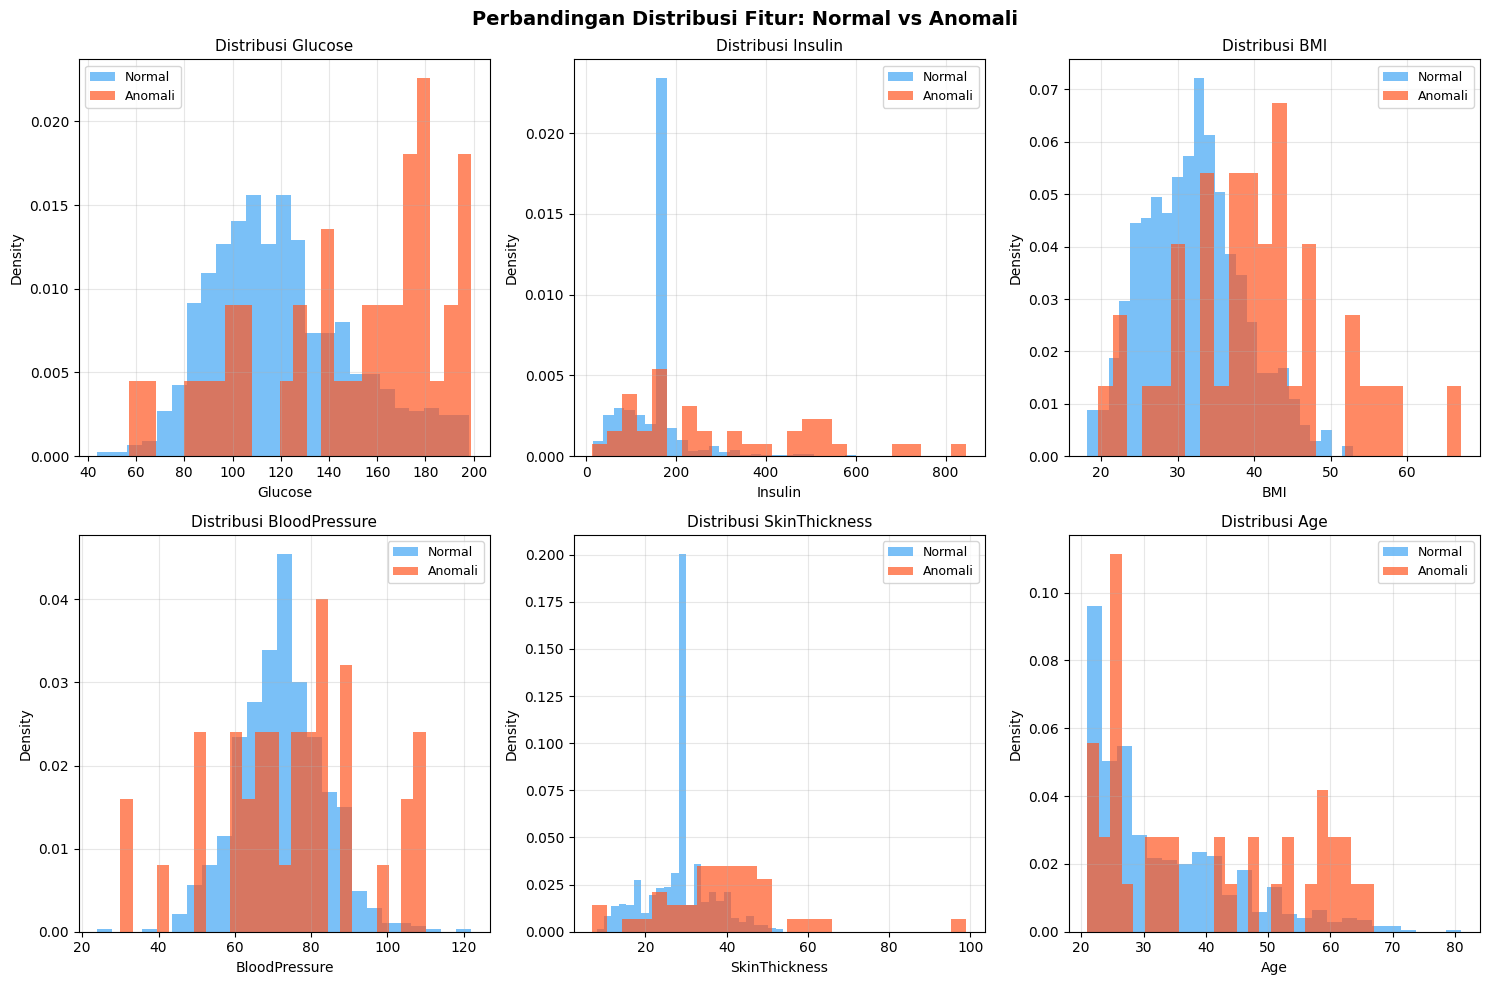

In [47]:
features_anomaly = ['Glucose', 'Insulin', 'BMI', 'BloodPressure', 'SkinThickness', 'Age']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feat in enumerate(features_anomaly):
    normal_data = dataset_anomaly[dataset_anomaly['Anomaly']==0][feat]
    anomaly_data = dataset_anomaly[dataset_anomaly['Anomaly']==1][feat]

    axes[idx].hist(normal_data, bins=25, color='#2196F3', alpha=0.6, label='Normal', density=True)
    axes[idx].hist(anomaly_data, bins=25, color='#FF5722', alpha=0.7, label='Anomali', density=True)
    axes[idx].set_title(f'Distribusi {feat}', fontsize=11)
    axes[idx].set_xlabel(feat)
    axes[idx].set_ylabel('Density')
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Perbandingan Distribusi Fitur: Normal vs Anomali', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Evaluasi Anomaly Detection

Karena Isolation Forest adalah unsupervised, evaluasi dilakukan dengan melihat seberapa banyak data anomali yang ternyata adalah kasus diabetes.

In [48]:
# Korelasi anomali dengan label diabetes
print('Tabel Silang: Anomali vs Outcome Diabetes')
cross_tab = pd.crosstab(
    dataset_anomaly['Anomaly'].map({0:'Normal', 1:'Anomali'}),
    dataset_anomaly['Outcome'].map({0:'Tidak Diabetes', 1:'Diabetes'}),
    margins=True
)
print(cross_tab)

anomaly_diabetes_rate = dataset_anomaly[dataset_anomaly['Anomaly']==1]['Outcome'].mean() * 100
normal_diabetes_rate = dataset_anomaly[dataset_anomaly['Anomaly']==0]['Outcome'].mean() * 100

print(f'\nTingkat diabetes pada data ANOMALI : {anomaly_diabetes_rate:.1f}%')
print(f'Tingkat diabetes pada data NORMAL  : {normal_diabetes_rate:.1f}%')

Tabel Silang: Anomali vs Outcome Diabetes
Outcome  Diabetes  Tidak Diabetes  All
Anomaly                               
Anomali        23              16   39
Normal        245             484  729
All           268             500  768

Tingkat diabetes pada data ANOMALI : 59.0%
Tingkat diabetes pada data NORMAL  : 33.6%


## Visualisasi Anomaly Score per Fitur (Top 10 Anomali Tertinggi)

Top 10 Data Paling Anomali:
     Glucose  BloodPressure  SkinThickness  Insulin   BMI  Age  Outcome  Anomaly_Score
445    180.0           78.0           63.0     14.0  59.4   25        1          -0.17
228    197.0           70.0           39.0    744.0  36.7   31        0          -0.12
247    165.0           90.0           33.0    680.0  52.3   23        0          -0.09
370    173.0           82.0           48.0    465.0  38.4   25        1          -0.08
8      197.0           70.0           45.0    543.0  30.5   53        1          -0.08
13     189.0           60.0           23.0    846.0  30.1   59        1          -0.08
4      137.0           40.0           35.0    168.0  43.1   33        1          -0.07
177    129.0          110.0           46.0    130.0  67.1   26        1          -0.06
519    129.0           90.0            7.0    326.0  19.6   60        0          -0.06
673    123.0          100.0           35.0    240.0  57.3   22        0          -0.05


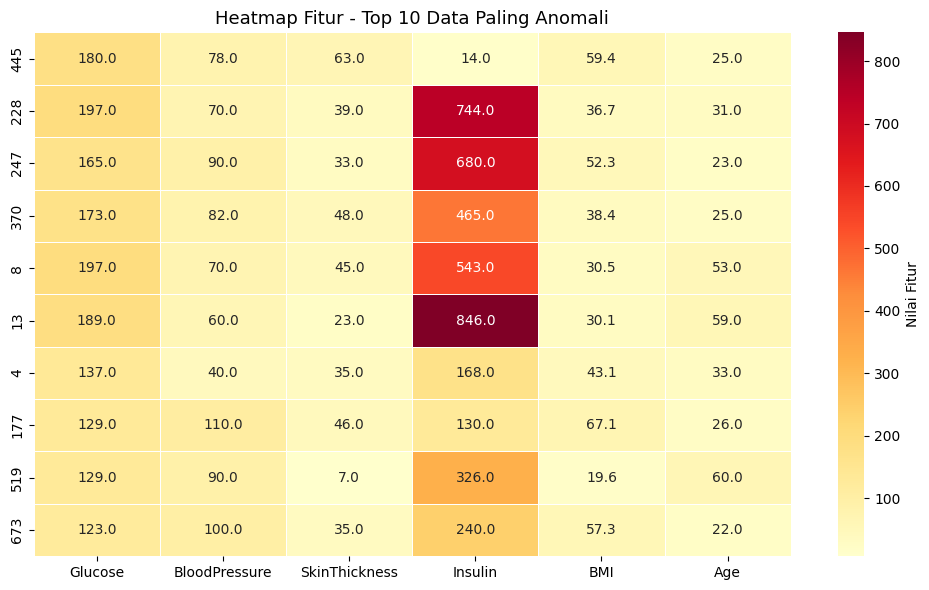

In [49]:
# Tampilkan 10 data dengan anomaly score terendah (paling anomali)
top_anomalies = dataset_anomaly.nsmallest(10, 'Anomaly_Score')[['Glucose','BloodPressure','SkinThickness',
                                                                    'Insulin','BMI','Age','Outcome','Anomaly_Score']]
print('Top 10 Data Paling Anomali:')
print(top_anomalies.round(2).to_string())

# Heatmap data anomali
plt.figure(figsize=(10, 6))
sns.heatmap(top_anomalies.drop(columns=['Outcome','Anomaly_Score']),
            annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Nilai Fitur'})
plt.title('Heatmap Fitur - Top 10 Data Paling Anomali', fontsize=13)
plt.tight_layout()
plt.show()

---
# 📊 RINGKASAN PERBANDINGAN SEMUA METODE

In [50]:
print('='*55)
print('          RINGKASAN SEMUA MODEL')
print('='*55)
print('\n[CLASSIFICATION — Random Forest]')
print(f'  Accuracy  : {score_rf:.2f}%')
print(f'  Precision : {precision_score(Y_test, Y_pred_rf):.4f}')
print(f'  Recall    : {recall_score(Y_test, Y_pred_rf):.4f}')
print(f'  F1 Score  : {f1_score(Y_test, Y_pred_rf):.4f}')
print('\n[CLUSTERING — K-Means]')
print(f'  K Optimal         : {best_k} cluster')
print(f'  Silhouette Score  : {sil_score:.4f}')
print(f'  Davies-Bouldin    : {db_score:.4f}')
print('\n[ANOMALY DETECTION — Isolation Forest]')
print(f'  Data Normal  : {n_normal} ({n_normal/len(anomaly_labels)*100:.1f}%)')
print(f'  Data Anomali : {n_anomaly} ({n_anomaly/len(anomaly_labels)*100:.1f}%)')
print(f'  Tingkat diabetes pada anomali: {anomaly_diabetes_rate:.1f}%')
print('='*55)

          RINGKASAN SEMUA MODEL

[CLASSIFICATION — Random Forest]
  Accuracy  : 74.68%
  Precision : 0.6667
  Recall    : 0.5556
  F1 Score  : 0.6061

[CLUSTERING — K-Means]
  K Optimal         : 3 cluster
  Silhouette Score  : 0.2452
  Davies-Bouldin    : 1.5791

[ANOMALY DETECTION — Isolation Forest]
  Data Normal  : 729 (94.9%)
  Data Anomali : 39 (5.1%)
  Tingkat diabetes pada anomali: 59.0%


## Simpan Model

In [52]:
pickle.dump(rf_tuned, open('model_classification.pkl', 'wb'))
pickle.dump(kmeans, open('model_clustering.pkl', 'wb'))
pickle.dump(iso_forest, open('model_anomaly.pkl', 'wb'))
pickle.dump(sc, open('scaler.pkl', 'wb'))

print('Semua model berhasil disimpan:')
print('  model_classification.pkl  -> Random Forest')
print('  model_clustering.pkl      -> K-Means')
print('  model_anomaly.pkl         -> Isolation Forest')
print('  scaler.pkl                -> MinMaxScaler')

Semua model berhasil disimpan:
  model_classification.pkl  -> Random Forest
  model_clustering.pkl      -> K-Means
  model_anomaly.pkl         -> Isolation Forest
  scaler.pkl                -> MinMaxScaler
